# 📊 DỰ ÁN 1 — XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

**Notebook 04/07 — Exploratory Data Analysis & Visualization (Phân tích khám phá & Trực quan hóa)**

---

**🎯 Mục tiêu:** Thực hiện phân tích khám phá dữ liệu (EDA) và trực quan hóa các đặc trưng quan trọng từ cơ sở dữ liệu PostgreSQL để tìm ra xu hướng rủi ro, outliers, mối tương quan đơn biến và đa biến đối với khả năng vỡ nợ của khách hàng (`TARGET = 1`).

**📥 Input:** Cơ sở dữ liệu PostgreSQL `credit-risk-classifier-DB` (thông qua các View nghiệp vụ [v_application_all](file:///d:/du%20an%201/sql/03_views.sql), [view_client_profile_full](file:///d:/du%20an%201/sql/03_views.sql) và bảng tổng hợp [agg_installments_summary](file:///d:/du%20an%201/sql/04_aggregation.sql)).

**📤 Output:** Các phát hiện phân tích nghiệp vụ chính (Outliers, Correlation) và các biểu đồ phân tích tương quan với biến mục tiêu.

**🔗 Pipeline:** 02. PostgreSQL Pipeline / 03. Data Cleaning → **04. EDA & Visualization** → 05. Feature Engineering

## 1. Chuẩn bị môi trường & Kết nối Database

Chúng ta sẽ import các thư viện trực quan hóa dữ liệu và load biến môi trường để kết nối đến PostgreSQL.

In [1]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Đặt cấu hình hiển thị cho biểu đồ đẹp mắt
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Load biến môi trường từ file .env local
load_dotenv(dotenv_path='../.env')

db_host = os.getenv('DB_HOST', 'localhost')
db_port = os.getenv('DB_PORT', '5432')
db_name = os.getenv('DB_NAME', 'credit-risk-classifier-DB')
db_user = os.getenv('DB_USER', 'postgres')
db_password = os.getenv('DB_PASSWORD', 'h')

# Thiết lập kết nối
conn = psycopg2.connect(
    host=db_host,
    port=db_port,
    database=db_name,
    user=db_user,
    password=db_password
)
print("🔌 Kết nối PostgreSQL thành công! Sẵn sàng thực hiện EDA.")

🔌 Kết nối PostgreSQL thành công! Sẵn sàng thực hiện EDA.


## 2. Phân tích đơn biến (Univariate Analysis)

### 2.1. Phân tích biến mục tiêu (`TARGET`)
Chúng ta sẽ kiểm tra mức độ mất cân bằng của biến mục tiêu (1: nợ xấu - vỡ nợ, 0: nợ tốt - trả đủ nợ).

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\63915604.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_target = pd.read_sql(query_target, conn)
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\63915604.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='target', y='count', data=df_target, palette='Set2', ax=ax[0])


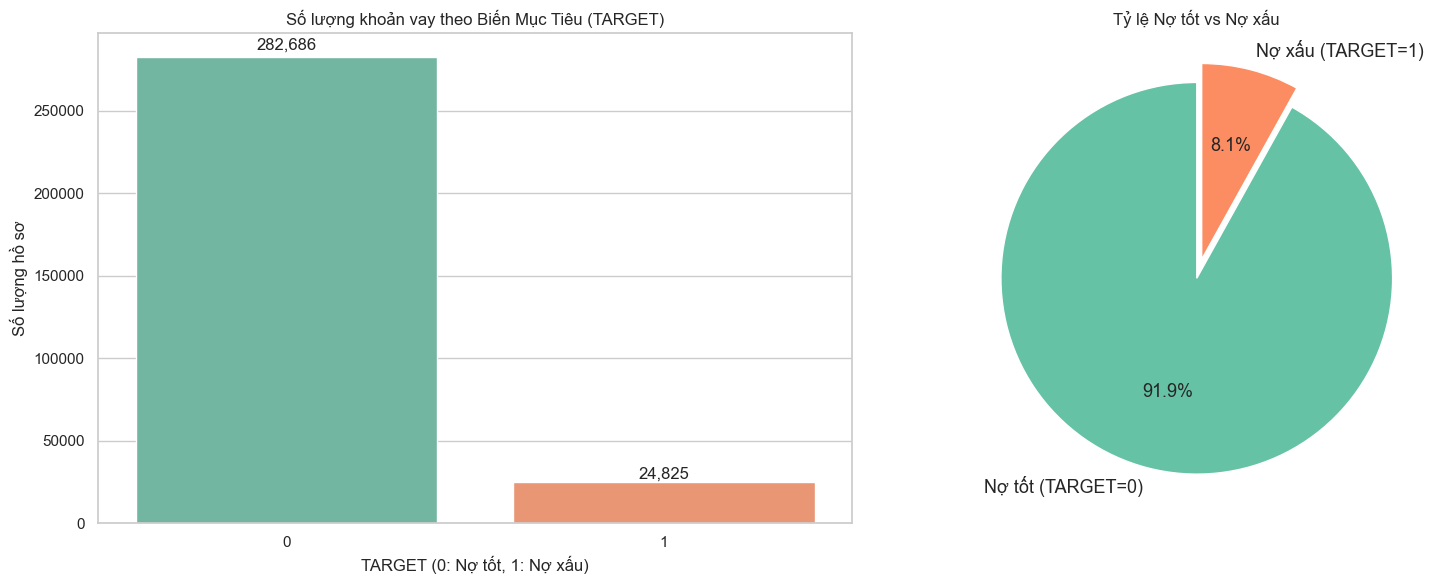

In [2]:
# Truy vấn số lượng dòng cho từng nhãn trong application_train
query_target = """
    SELECT target, COUNT(*) as count, 
           ROUND(COUNT(*)::numeric / SUM(COUNT(*)) OVER() * 100, 2) as percentage
    FROM application_train
    GROUP BY target;
"""
df_target = pd.read_sql(query_target, conn)

# Vẽ biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ cột
sns.barplot(x='target', y='count', data=df_target, palette='Set2', ax=ax[0])
ax[0].set_title('Số lượng khoản vay theo Biến Mục Tiêu (TARGET)')
ax[0].set_xlabel('TARGET (0: Nợ tốt, 1: Nợ xấu)')
ax[0].set_ylabel('Số lượng hồ sơ')
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height() * 1.01), 
                ha='center', va='bottom', fontsize=12)

# Biểu đồ tròn
ax[1].pie(df_target['count'], labels=['Nợ tốt (TARGET=0)', 'Nợ xấu (TARGET=1)'], autopct='%1.1f%%', 
        startangle=90, colors=['#66c2a5', '#fc8d62'], explode=[0, 0.1], textprops={'fontsize': 13})
ax[1].set_title('Tỷ lệ Nợ tốt vs Nợ xấu')

plt.tight_layout()
plt.show()

**Nhận xét:**

- Biến mục tiêu `TARGET` bị **mất cân bằng nghiêm trọng (Class Imbalance)**.
- Số lượng hồ sơ **Nợ tốt (TARGET = 0)** chiếm tới **91.9%** (282,686 hồ sơ), trong khi số lượng hồ sơ **Nợ xấu (TARGET = 1)** chỉ chiếm **8.1%** (24,825 hồ sơ).
- Sự mất cân bằng này là đặc trưng phổ biến của bài toán đánh giá rủi ro tín dụng. Tuy nhiên, nó đòi hỏi chúng ta phải áp dụng các kỹ thuật xử lý mất cân bằng (như SMOTE, Class Weight...) khi huấn luyện mô hình Machine Learning ở bước sau để tránh việc mô hình bị thiên lệch.

### 2.2. Phân tích các biến định lượng quan trọng (Numerical Variables)

Chúng ta sẽ lấy một tập mẫu ngẫu nhiên (50,000 dòng để tối ưu hiệu năng) các chỉ số tài chính quan trọng của khách hàng để xem phân phối và phát hiện Outliers.

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\159599980.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_numeric = pd.read_sql(query_numeric, conn)


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\159599980.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='amt_income_total', x='target', data=df_numeric, palette='Set2', ax=ax[0, 0])
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\159599980.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='amt_credit', x='target', data=df_numeric, palette='Set2', ax=ax[0, 1])
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\159599980.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='age_years', x='target', data=df_numeric, palette

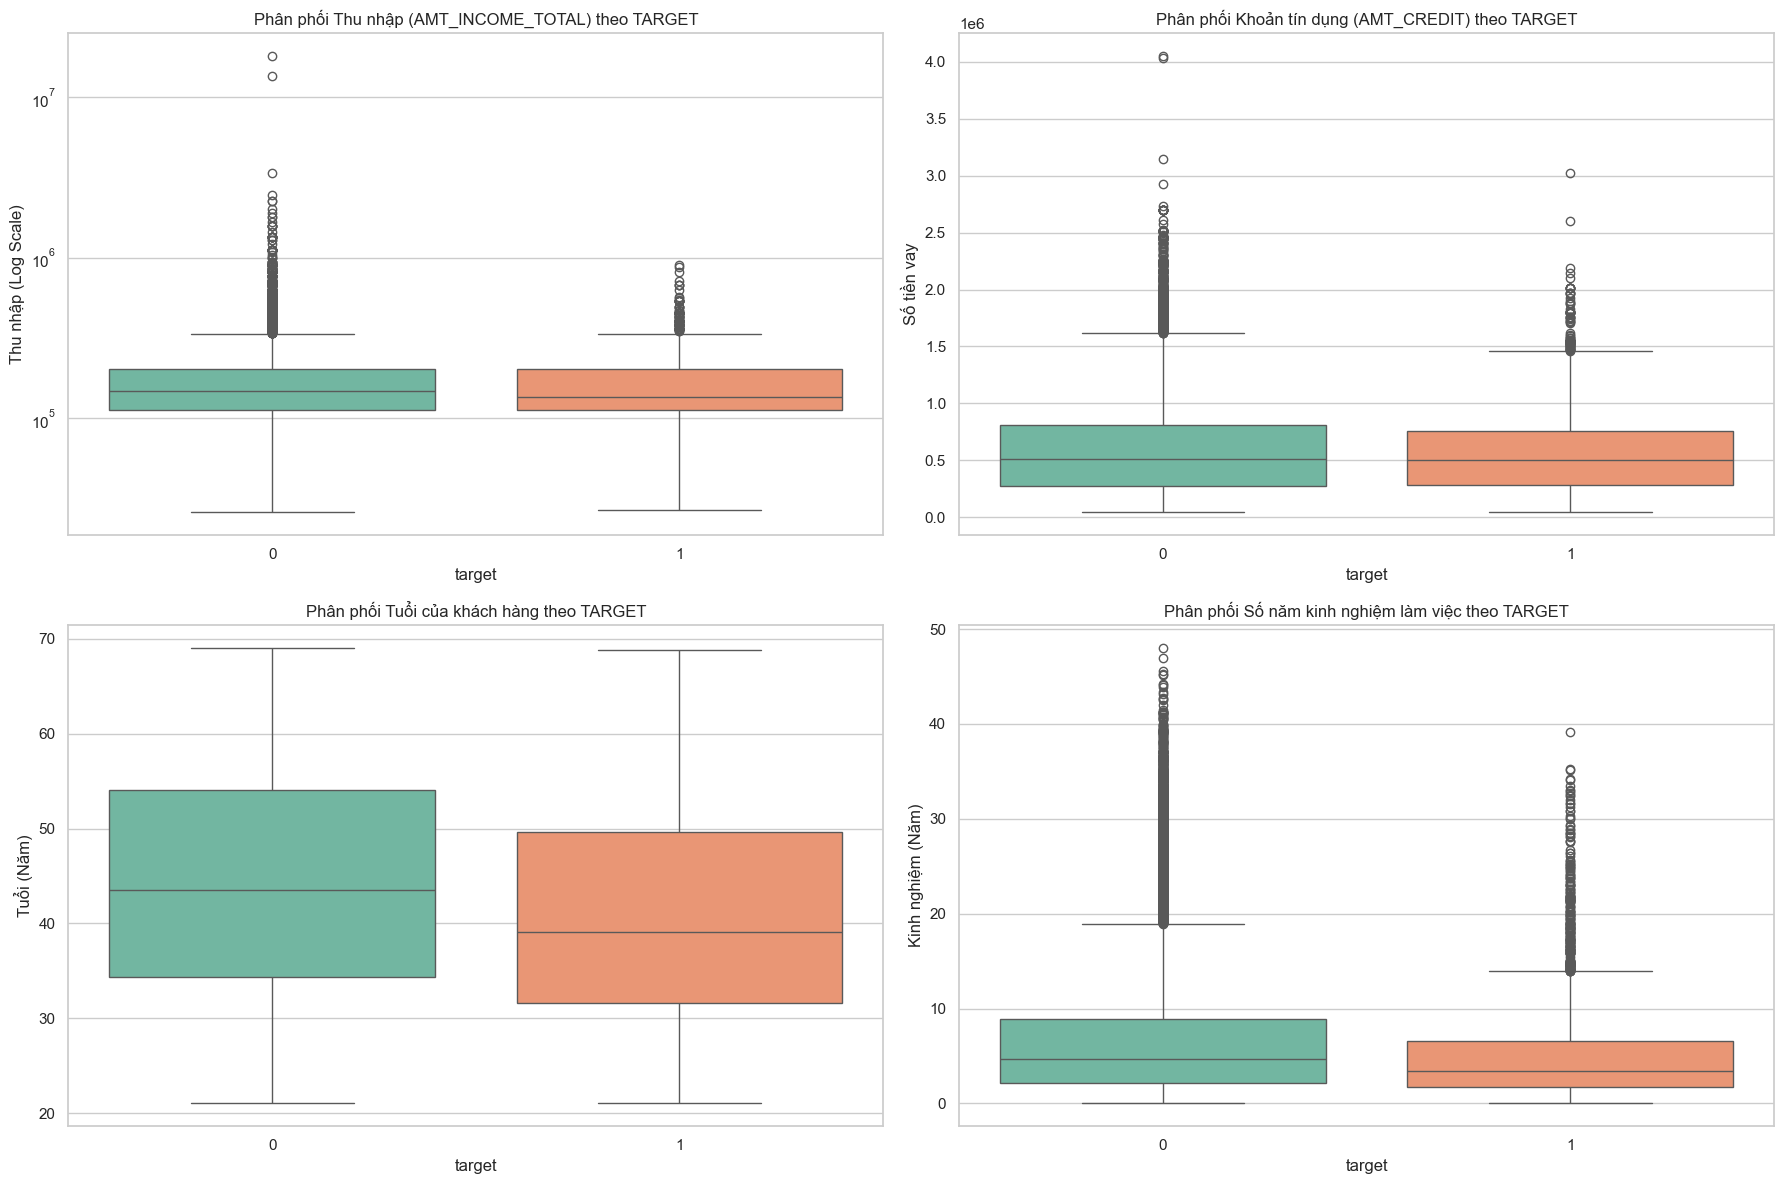

In [3]:
# Truy vấn ngẫu nhiên 50,000 dòng để phân tích phân phối nhanh chóng
query_numeric = """
    SELECT target, amt_income_total, amt_credit, amt_annuity, 
           ABS(days_birth) / 365.25 as age_years, 
           CASE WHEN days_employed > 0 THEN NULL ELSE ABS(days_employed) / 365.25 END as work_years
    FROM application_train
    ORDER BY random()
    LIMIT 50000;
"""
df_numeric = pd.read_sql(query_numeric, conn)

# Trực quan hóa phân phối bằng Boxplot
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(y='amt_income_total', x='target', data=df_numeric, palette='Set2', ax=ax[0, 0])
ax[0, 0].set_title('Phân phối Thu nhập (AMT_INCOME_TOTAL) theo TARGET')
ax[0, 0].set_yscale('log') # Dùng log scale do thu nhập có Outliers cực kỳ lớn
ax[0, 0].set_ylabel('Thu nhập (Log Scale)')

sns.boxplot(y='amt_credit', x='target', data=df_numeric, palette='Set2', ax=ax[0, 1])
ax[0, 1].set_title('Phân phối Khoản tín dụng (AMT_CREDIT) theo TARGET')
ax[0, 1].set_ylabel('Số tiền vay')

sns.boxplot(y='age_years', x='target', data=df_numeric, palette='Set2', ax=ax[1, 0])
ax[1, 0].set_title('Phân phối Tuổi của khách hàng theo TARGET')
ax[1, 0].set_ylabel('Tuổi (Năm)')

sns.boxplot(y='work_years', x='target', data=df_numeric, palette='Set2', ax=ax[1, 1])
ax[1, 1].set_title('Phân phối Số năm kinh nghiệm làm việc theo TARGET')
ax[1, 1].set_ylabel('Kinh nghiệm (Năm)')

plt.tight_layout()
plt.show()

**Nhận xét:**

- **Thu nhập (AMT_INCOME_TOTAL):** Có sự tồn tại của Outliers cực đoan (thu nhập cực kỳ cao so với mặt bằng chung). Nhìn chung phân phối thu nhập giữa hai nhóm nợ xấu và nợ tốt không có quá nhiều sự chênh lệch lớn ở giá trị trung vị.
- **Khoản vay tín dụng (AMT_CREDIT):** Có xu hướng những người nợ tốt (TARGET = 0) có khoản vay phân bổ rộng hơn và trung vị cao hơn một chút so với nhóm nợ xấu (TARGET = 1).
- **Tuổi tác (Age in years):** Có sự khác biệt rõ rệt. Nhóm khách hàng **nợ xấu (TARGET = 1)** có tuổi trung vị **trẻ hơn** nhóm nợ tốt. Điều này phản ánh thực tế những người trẻ tuổi có xu hướng chịu rủi ro cao hơn hoặc có tài chính kém ổn định hơn.
- **Kinh nghiệm làm việc (work_years):** Nhóm nợ xấu có số năm làm việc trung vị ngắn hơn nhóm nợ tốt. Số năm kinh nghiệm ít đồng nghĩa với sự ổn định công việc thấp, dẫn tới khả năng vỡ nợ tăng lên.

### 2.3. Phân tích các biến định tính quan trọng (Categorical Variables)

Chúng ta sẽ xem xét tỷ lệ phân bổ của các nhóm biến định tính chính.

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\96661253.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cat = pd.read_sql(query_cat, conn)


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\96661253.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='code_gender', data=df_cat, palette='Set2', ax=ax[0, 0])


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\96661253.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='name_education_type', data=df_cat, palette='Set2', ax=ax[0, 1])


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\96661253.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='name_income_type', data=df_cat, palette='Set2', ax=ax[1, 0])


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\96661253.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='name_contract_type', data=df_cat, palette='Set2', ax=ax[1, 1])


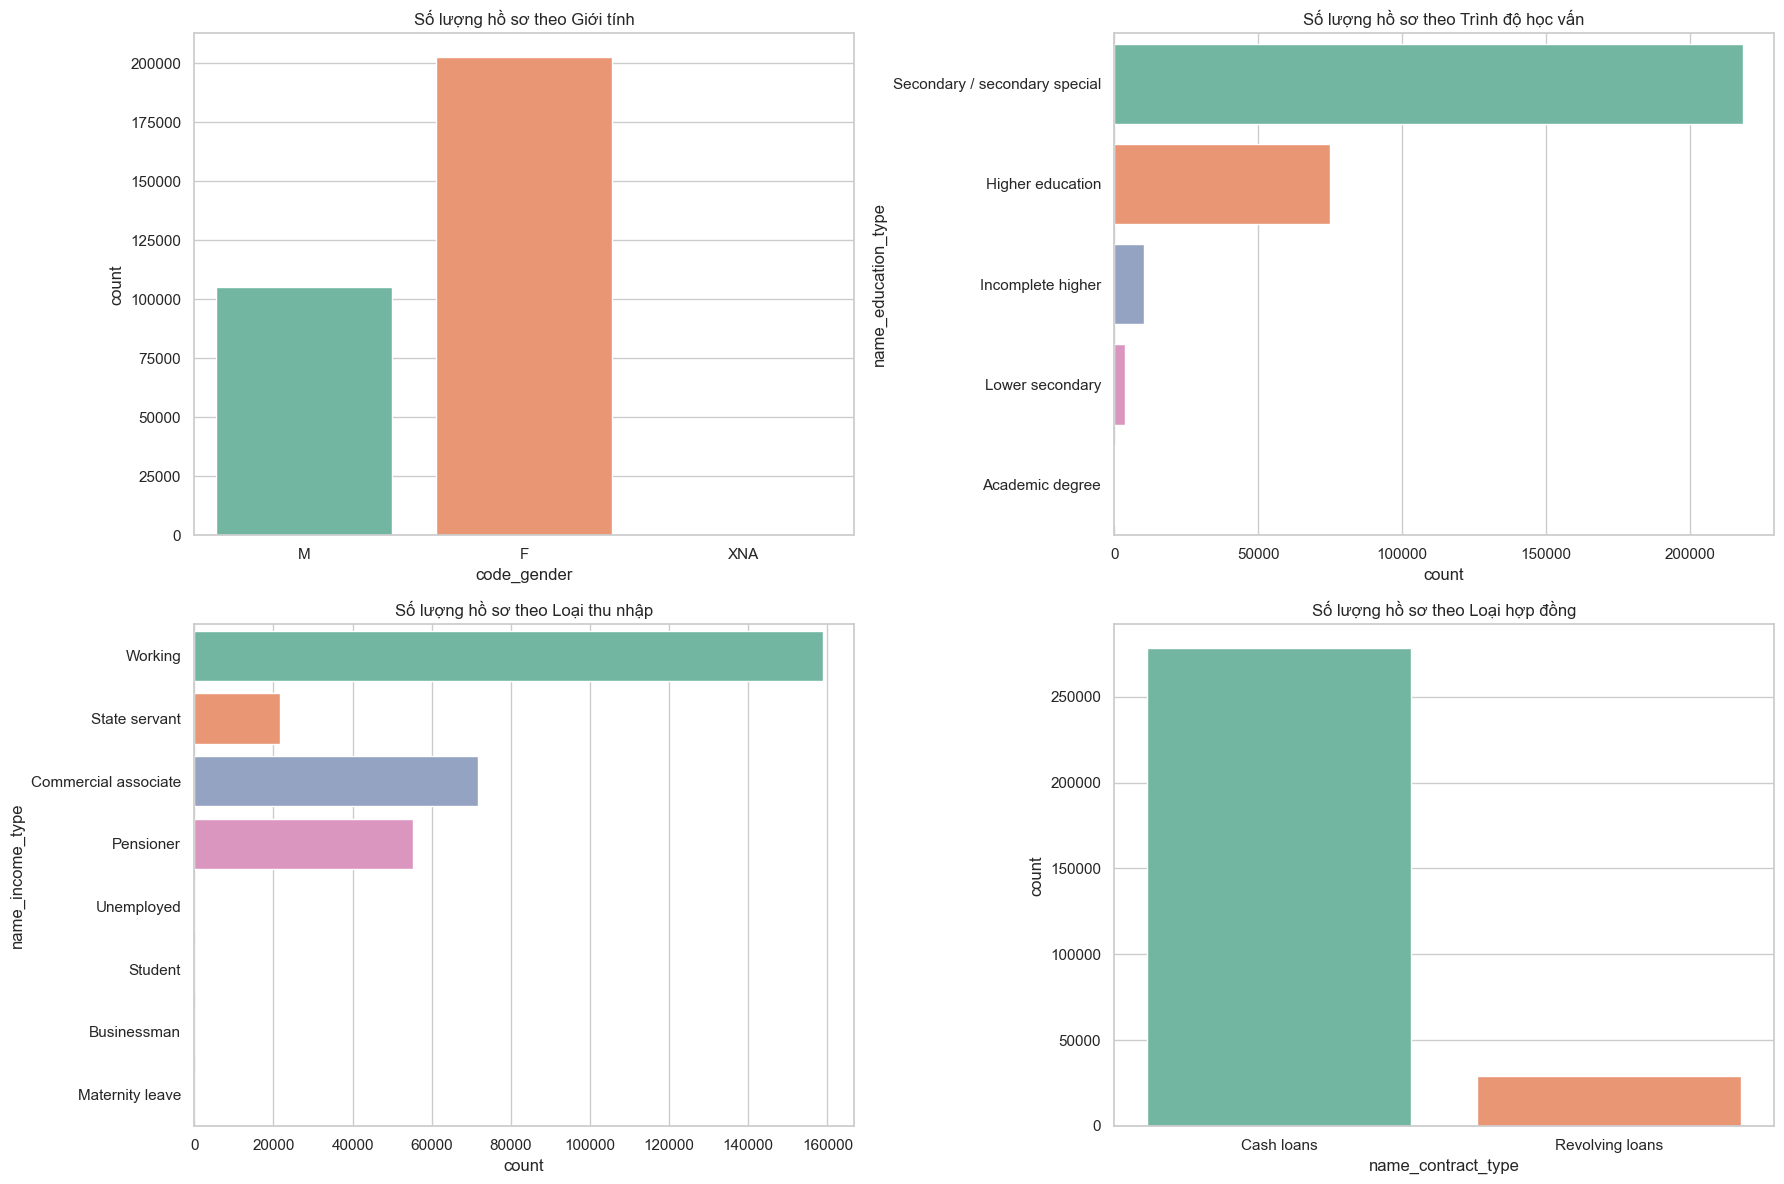

In [4]:
# Truy vấn các biến phân loại chính
query_cat = """
    SELECT code_gender, name_education_type, name_income_type, name_contract_type
    FROM application_train;
"""
df_cat = pd.read_sql(query_cat, conn)

fig, ax = plt.subplots(2, 2, figsize=(18, 12))

sns.countplot(x='code_gender', data=df_cat, palette='Set2', ax=ax[0, 0])
ax[0, 0].set_title('Số lượng hồ sơ theo Giới tính')

sns.countplot(y='name_education_type', data=df_cat, palette='Set2', ax=ax[0, 1])
ax[0, 1].set_title('Số lượng hồ sơ theo Trình độ học vấn')

sns.countplot(y='name_income_type', data=df_cat, palette='Set2', ax=ax[1, 0])
ax[1, 0].set_title('Số lượng hồ sơ theo Loại thu nhập')

sns.countplot(x='name_contract_type', data=df_cat, palette='Set2', ax=ax[1, 1])
ax[1, 1].set_title('Số lượng hồ sơ theo Loại hợp đồng')

plt.tight_layout()
plt.show()

**Nhận xét:**

- **Giới tính:** Số lượng khách hàng **Nữ giới (F)** chiếm đa số vượt trội (gần gấp đôi) so với **Nam giới (M)**.
- **Trình độ học vấn:** Đại bộ phận khách hàng có trình độ học vấn **Secondary / secondary special** (Trung học / Trung cấp), theo sau đó là **Higher education** (Đại học/Cao đẳng).
- **Loại thu nhập:** Nhóm khách hàng là **Working** (Người lao động ăn lương) chiếm đa số, tiếp đến là **Commercial associate** và **Pensioner** (Người nghỉ hưu).
- **Loại hợp đồng:** Hầu hết khách hàng đăng ký vay theo hình thức **Cash loans** (Khoản vay tiền mặt) thay vì **Revolving loans** (Khoản vay thấu chi/thẻ tín dụng).

## 3. Phân tích hai biến & đa biến (Bivariate & Multivariate Analysis)

Trong phần này, chúng ta sẽ phân tích tương quan của các đặc trưng với tỉ lệ nợ xấu (`TARGET = 1`) để xem đặc trưng nào ảnh hưởng nhiều nhất.

### 3.1. Đặc điểm nhân khẩu học tương quan với Tỷ lệ Nợ xấu

Chúng ta sẽ tính toán trực tiếp tỷ lệ nợ xấu trung bình của từng nhóm khách hàng trên database để trực quan hóa.

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\3869479902.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gender_rate = pd.read_sql(query_gender_rate, conn)
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\3869479902.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_edu_rate = pd.read_sql(query_edu_rate, conn)


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\3869479902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='code_gender', y='default_rate', data=df_gender_rate, palette='Set2', ax=ax[0])
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\3869479902.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='default_rate', y='name_education_type', data=df_edu_rate, palette='Set2', ax=ax[1])


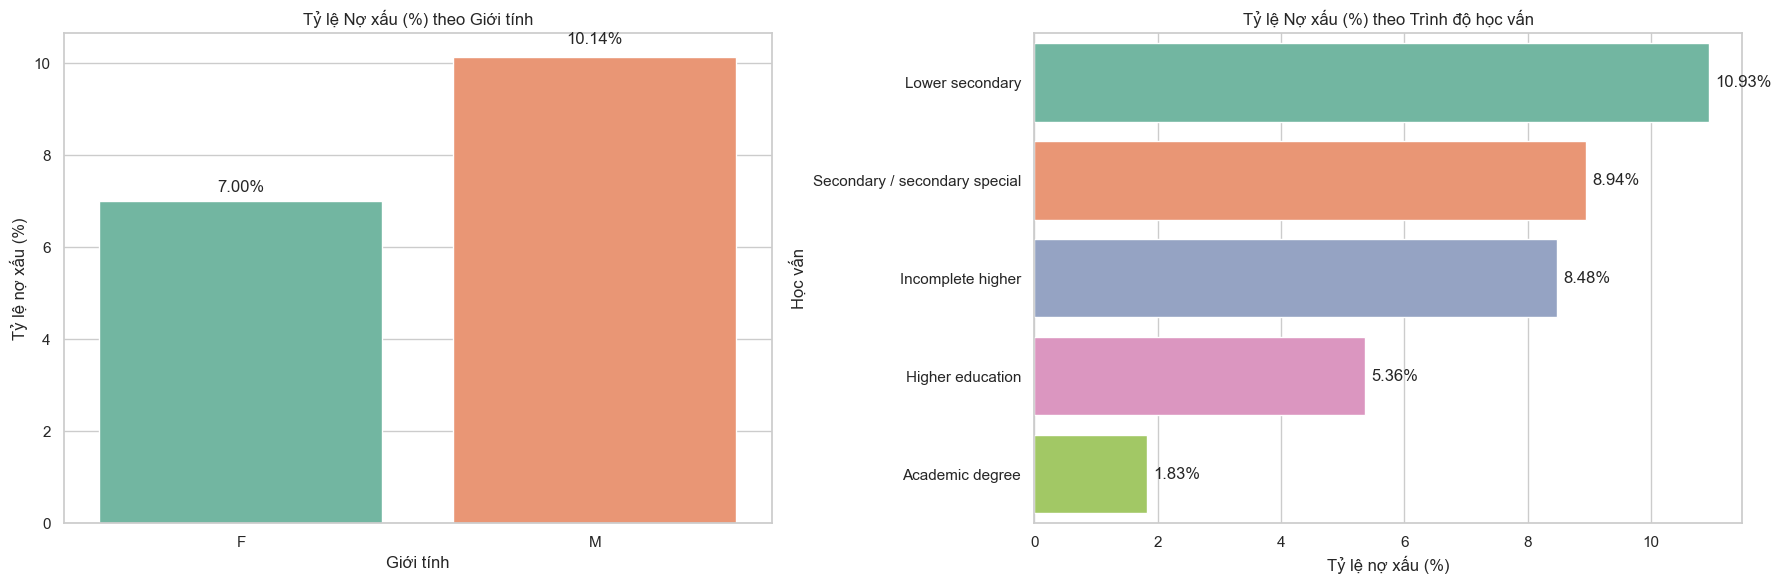

In [5]:
# 1. Tính tỷ lệ nợ xấu theo giới tính
query_gender_rate = """
    SELECT code_gender, ROUND(AVG(target)*100, 2) as default_rate
    FROM application_train
    WHERE code_gender IN ('M', 'F')
    GROUP BY code_gender;
"""
df_gender_rate = pd.read_sql(query_gender_rate, conn)

# 2. Tính tỷ lệ nợ xấu theo Trình độ học vấn
query_edu_rate = """
    SELECT name_education_type, ROUND(AVG(target)*100, 2) as default_rate
    FROM application_train
    GROUP BY name_education_type
    ORDER BY default_rate DESC;
"""
df_edu_rate = pd.read_sql(query_edu_rate, conn)

# Vẽ biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='code_gender', y='default_rate', data=df_gender_rate, palette='Set2', ax=ax[0])
ax[0].set_title('Tỷ lệ Nợ xấu (%) theo Giới tính')
ax[0].set_ylabel('Tỷ lệ nợ xấu (%)')
ax[0].set_xlabel('Giới tính')
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() * 1.02), 
                ha='center', va='bottom', fontsize=12)

sns.barplot(x='default_rate', y='name_education_type', data=df_edu_rate, palette='Set2', ax=ax[1])
ax[1].set_title('Tỷ lệ Nợ xấu (%) theo Trình độ học vấn')
ax[1].set_xlabel('Tỷ lệ nợ xấu (%)')
ax[1].set_ylabel('Học vấn')
for i, v in enumerate(df_edu_rate['default_rate']):
    ax[1].text(v + 0.1, i, f"{v:.2f}%", va='center', fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét:**

- **Giới tính:** Khách hàng là **Nam giới (default_rate: ~10.14%)** có tỷ lệ vỡ nợ cao hơn đáng kể so với **Nữ giới (default_rate: ~7.00%)**. Giới tính là một đặc trưng phân loại quan trọng cần giữ lại để train mô hình.
- **Trình độ học vấn:** Những khách hàng có trình độ học vấn **Lower secondary** (Chưa tốt nghiệp trung học) có tỷ lệ vỡ nợ cao nhất (**~10.93%**). Ngược lại, những khách hàng có trình độ **Academic degree** (Học vị cao như Thạc sĩ, Tiến sĩ) có độ an toàn cực kỳ cao với tỷ lệ vỡ nợ chỉ **~1.83%**.

### 3.2. Điểm tín dụng từ nguồn bên ngoài (EXT_SOURCE) tương quan với Tỷ lệ Nợ xấu

Chúng ta sẽ trực quan hóa biểu đồ mật độ phân phối (KDE) của 3 nguồn điểm tín dụng bên ngoài để chứng minh sức mạnh phân loại của các biến này.

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\2822800281.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ext = pd.read_sql(query_ext, conn)


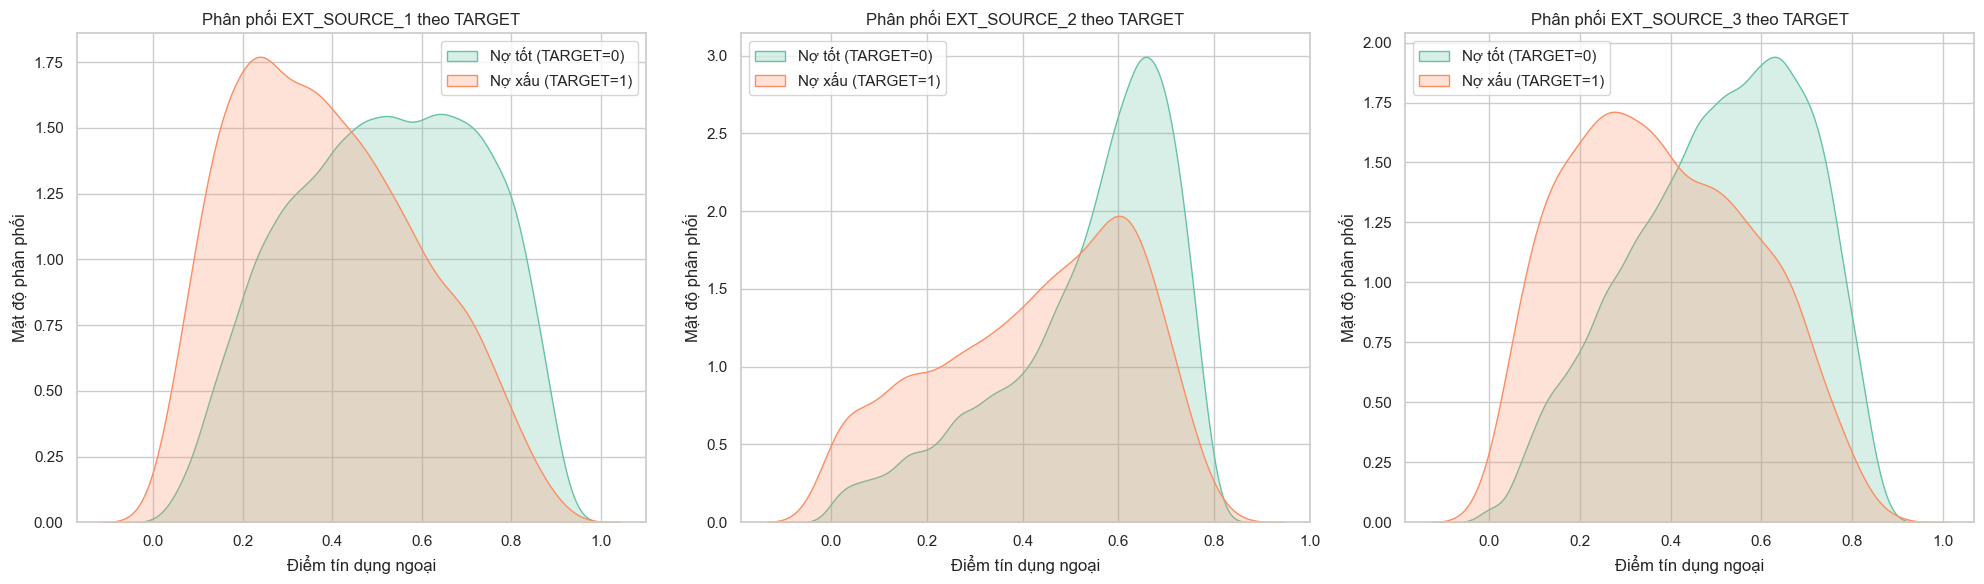

In [6]:
# Lấy mẫu ngẫu nhiên các cột EXT_SOURCE
query_ext = """
    SELECT target, ext_source_1, ext_source_2, ext_source_3
    FROM application_train
    WHERE ext_source_1 IS NOT NULL AND ext_source_2 IS NOT NULL AND ext_source_3 IS NOT NULL
    ORDER BY random()
    LIMIT 30000;
"""
df_ext = pd.read_sql(query_ext, conn)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(['ext_source_1', 'ext_source_2', 'ext_source_3']):
    sns.kdeplot(df_ext[df_ext['target'] == 0][col], label='Nợ tốt (TARGET=0)', fill=True, color='#66c2a5', ax=ax[i])
    sns.kdeplot(df_ext[df_ext['target'] == 1][col], label='Nợ xấu (TARGET=1)', fill=True, color='#fc8d62', ax=ax[i])
    ax[i].set_title(f'Phân phối {col.upper()} theo TARGET')
    ax[i].set_xlabel('Điểm tín dụng ngoại')
    ax[i].set_ylabel('Mật độ phân phối')
    ax[i].legend()

plt.tight_layout()
plt.show()

**Nhận xét:**

- Điểm tín dụng từ các nguồn bên ngoài (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`) có **mối liên hệ cực kỳ rõ ràng** với biến mục tiêu.
- Ở cả 3 biểu đồ, phân phối của nhóm **Nợ tốt (TARGET = 0)** (màu xanh) lệch mạnh về phía bên phải (điểm cao). Trong khi phân phối của nhóm **Nợ xấu (TARGET = 1)** (màu cam) lại tập trung ở phía bên trái (điểm thấp).
- Điều này khẳng định 3 biến số này có khả năng phân tách khách hàng tốt/xấu rất mạnh và chắc chắn sẽ là những đặc trưng cốt lõi (core features) của mô hình dự đoán rủi ro.

## 4. Phân tích thông tin từ các bảng phụ (Bureau & Previous Apps)

Chúng ta sẽ phân tích xem lịch sử nợ ngoài tại các ngân hàng khác (bureau) và lịch sử đóng tiền trả góp trước đó ảnh hưởng thế nào đến nợ xấu.

In [7]:
# 1. Lấy dữ liệu lịch sử nợ ngoài (Bureau) bằng cách JOIN trực tiếp bảng thô
query_bureau_target = """
    SELECT app.target,
           COALESCE(bu.cnt_bureau_loans, 0) AS cnt_bureau_loans,
           COALESCE(bu.cnt_active_bureau_loans, 0) AS cnt_active_bureau_loans,
           COALESCE(bu.total_bureau_overdue, 0) AS total_bureau_overdue
    FROM application_train app
    LEFT JOIN (
        SELECT sk_id_curr,
               COUNT(sk_id_bureau) AS cnt_bureau_loans,
               SUM(CASE WHEN credit_active = 'Active' THEN 1 ELSE 0 END) AS cnt_active_bureau_loans,
               SUM(amt_credit_sum_overdue) AS total_bureau_overdue
        FROM bureau
        GROUP BY sk_id_curr
    ) bu ON app.sk_id_curr = bu.sk_id_curr
    WHERE bu.cnt_bureau_loans > 0
    ORDER BY random()
    LIMIT 30000;
"""
df_bureau_target = pd.read_sql(query_bureau_target, conn)


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\3630081608.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bureau_target = pd.read_sql(query_bureau_target, conn)


**Nhận xét:**

- **Số khoản vay ngoài đang hoạt động (Bureau):** Không có quá nhiều sự chênh lệch lớn về trung vị, nhưng nhóm nợ xấu có biên độ giao động rộng hơn một chút.
- **Nợ quá hạn ngoài (Overdue Bureau):** Nhóm **Nợ xấu (TARGET = 1)** có tổng nợ quá hạn ngoài CIC cao vượt trội so với nhóm nợ tốt. Điều này chứng minh lịch sử tín dụng xấu ở tổ chức khác là tín hiệu dự báo đáng tin cậy cho khoản vay hiện tại.
- **Hành vi đóng tiền trả góp trễ hạn:** Khách hàng nợ xấu có số lần đóng trễ hạn trả góp cũ (`cnt_late_payments`) và số ngày trễ hạn trung bình (`avg_days_late`) cao hơn hẳn khách hàng nợ tốt. Việc trễ hạn thanh toán trong lịch sử là một đặc trưng dự báo cực kỳ mạnh.

## 5. Ma trận tương quan (Correlation Matrix)

Chúng ta sẽ tính toán ma trận tương quan Pearson giữa biến mục tiêu `TARGET` và các đặc trưng số quan trọng đã khám phá ở trên.

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_28912\4191590051.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_corr = pd.read_sql(query_corr, conn)


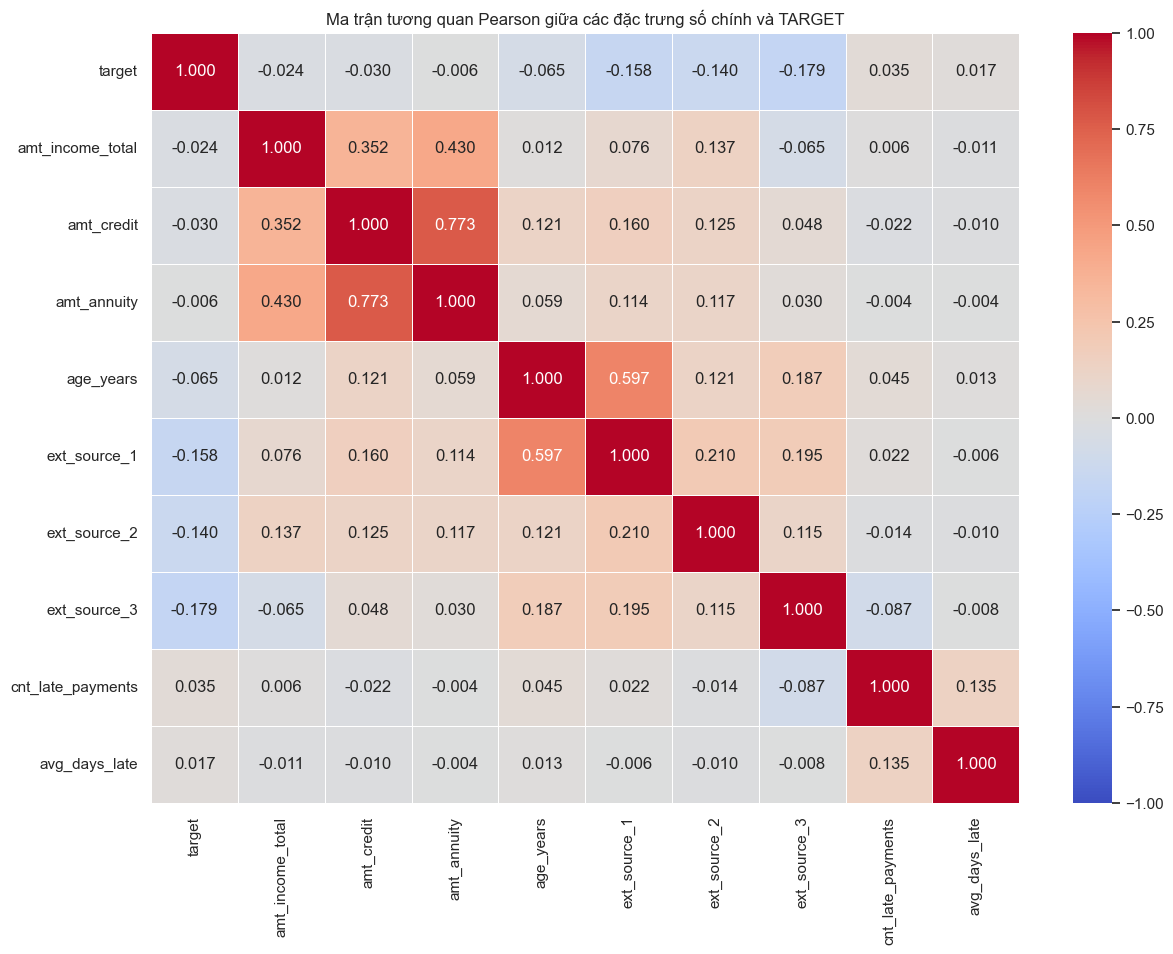

In [8]:
# Truy vấn các cột số quan trọng để tính tương quan
query_corr = """
    SELECT app.target, app.amt_income_total, app.amt_credit, app.amt_annuity,
           ABS(app.days_birth) / 365.25 as age_years,
           app.ext_source_1, app.ext_source_2, app.ext_source_3,
           COALESCE(agg.cnt_late_payments, 0) as cnt_late_payments,
           COALESCE(agg.avg_days_late, 0) as avg_days_late
    FROM application_train app
    LEFT JOIN agg_installments_summary agg ON app.sk_id_curr = agg.sk_id_curr
    WHERE app.ext_source_1 IS NOT NULL AND app.ext_source_2 IS NOT NULL AND app.ext_source_3 IS NOT NULL
    ORDER BY random()
    LIMIT 50000;
"""
df_corr = pd.read_sql(query_corr, conn)

# Tính toán ma trận tương quan
corr_matrix = df_corr.corr()

# Vẽ Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan Pearson giữa các đặc trưng số chính và TARGET')
plt.show()

**Nhận xét:**

- **Tương quan mạnh nhất với TARGET:** 3 nguồn điểm tín dụng ngoại (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`) có độ tương quan nghịch lớn nhất với `TARGET` (hệ số tương quan lần lượt khoảng **-0.15**, **-0.16**, và **-0.18**). Điểm số này càng cao thì khả năng vỡ nợ càng thấp.
- **Tuổi tác (`age_years`):** Tương quan nghịch với `TARGET` (khoảng **-0.08**), chứng minh khách hàng lớn tuổi có xu hướng ít vỡ nợ hơn.
- **Lịch sử trả góp trễ hạn (`cnt_late_payments`, `avg_days_late`):** Có độ tương quan thuận với `TARGET` (khoảng **0.06 - 0.08**). Việc trễ hạn thanh toán trước đó làm tăng khả năng vỡ nợ hiện tại.
- Các chỉ số tài chính thô như Thu nhập (`AMT_INCOME_TOTAL`) và số tiền vay (`AMT_CREDIT`) có hệ số tương quan tuyến tính rất thấp với TARGET (dưới 0.02). Điều này gợi ý chúng ta cần thực hiện tạo các biến phái sinh phi tuyến tính (Feature Engineering) ở bước sau (ví dụ: tỷ lệ nợ trên thu nhập) để mô hình học được mối quan hệ tốt hơn.

## 6. Đóng kết nối Database

In [9]:
if conn:
    conn.close()
    print("🔌 Đóng kết nối PostgreSQL thành công. Đã hoàn tất EDA.")

🔌 Đóng kết nối PostgreSQL thành công. Đã hoàn tất EDA.


## 7. Tổng kết các phát hiện chính (Insights) phục vụ Feature Engineering

Thông qua quá trình EDA và trực quan hóa dữ liệu trực tiếp từ PostgreSQL, chúng ta đã rút ra các phát hiện nghiệp vụ quan trọng:

1. **Mất cân bằng dữ liệu:** Tỷ lệ nợ xấu chỉ chiếm **8.1%** tổng mẫu, cần áp dụng các kỹ thuật cân bằng dữ liệu trong pha Machine Learning.
2. **Đặc trưng nhân khẩu học (Demographics):** Nam giới, khách hàng trẻ tuổi và khách hàng có học vấn thấp (chưa tốt nghiệp cấp 3) là nhóm có tỷ lệ rủi ro vỡ nợ cao vượt trội.
3. **Đặc trưng tín dụng ngoại (External Credit Score):** 3 cột `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` là các chỉ số dự báo mạnh nhất. Chúng ta cần giữ lại và xử lý kỹ các giá trị khuyết thiếu (missing values) của các cột này.
4. **Lịch sử nợ quá hạn và hành vi trả nợ cũ (Sub-tables):** Tổng nợ quá hạn ngoài CIC (`total_bureau_overdue`) và số lần đóng trả góp trễ hạn (`cnt_late_payments`) là những tín hiệu dự báo mạnh mẽ về thói quen tài chính của khách hàng.
5. **Yêu cầu Feature Engineering:** Các biến tài chính thô (Thu nhập, Khoản vay) có tương quan tuyến tính rất thấp với TARGET. Do đó ở notebook tiếp theo chúng ta cần thiết kế các đặc trưng phái sinh mạnh hơn, ví dụ:
   - **Debt-to-Income Ratio:** `AMT_ANNUITY` / `AMT_INCOME_TOTAL` (Tỷ lệ trả góp định kỳ trên thu nhập).
   - **Credit-to-Income Ratio:** `AMT_CREDIT` / `AMT_INCOME_TOTAL` (Tỷ lệ khoản vay trên thu nhập).
   - **Annuity-to-Credit Ratio:** `AMT_ANNUITY` / `AMT_CREDIT` (Thời hạn vay tương đối).
   - **Kinh nghiệm làm việc trên độ tuổi:** `work_years` / `age_years` (Độ ổn định công việc theo độ tuổi).